t =  0.0s | Overlaps: [-0.01043781  0.03884528 -0.01693072]
t =  5.0s | Overlaps: [-0.13474146  0.07656335  0.02825629]
t = 10.0s | Overlaps: [0.14599691 0.19051272 0.030868  ]
t = 15.0s | Overlaps: [ 0.04934335 -0.23422373 -0.04894957]
t = 20.0s | Overlaps: [-0.13243347 -0.2716653  -0.01402093]
t = 25.0s | Overlaps: [ 0.10403966  0.04225875 -0.36325487]


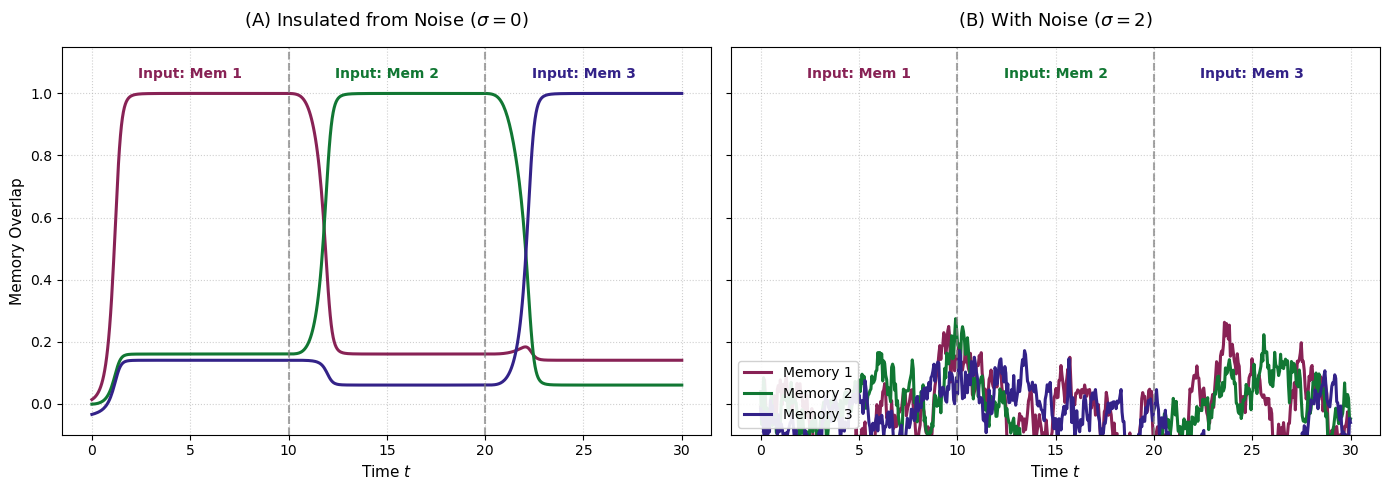

In [2]:
# Execute the original script to load functions and variables
%run IDP_Implementation.ipynb

t =  0.0s | Overlaps: [ 0.050791   -0.0780857   0.05944568 -0.03015001  0.01242179]
t =  5.0s | Overlaps: [ 0.9764759  -0.00109158  0.27523201  0.07727163  0.03959902]
t = 10.0s | Overlaps: [0.97597378 0.00108588 0.27587729 0.08117129 0.04079737]
t = 15.0s | Overlaps: [ 0.00137413  0.9736541  -0.07469165  0.28366898  0.07999122]
t = 20.0s | Overlaps: [ 0.00185661  0.98124401 -0.07483042  0.28419827  0.08366836]
t = 25.0s | Overlaps: [-0.01217351  0.05030596 -0.0025535   0.06221283  0.01444077]


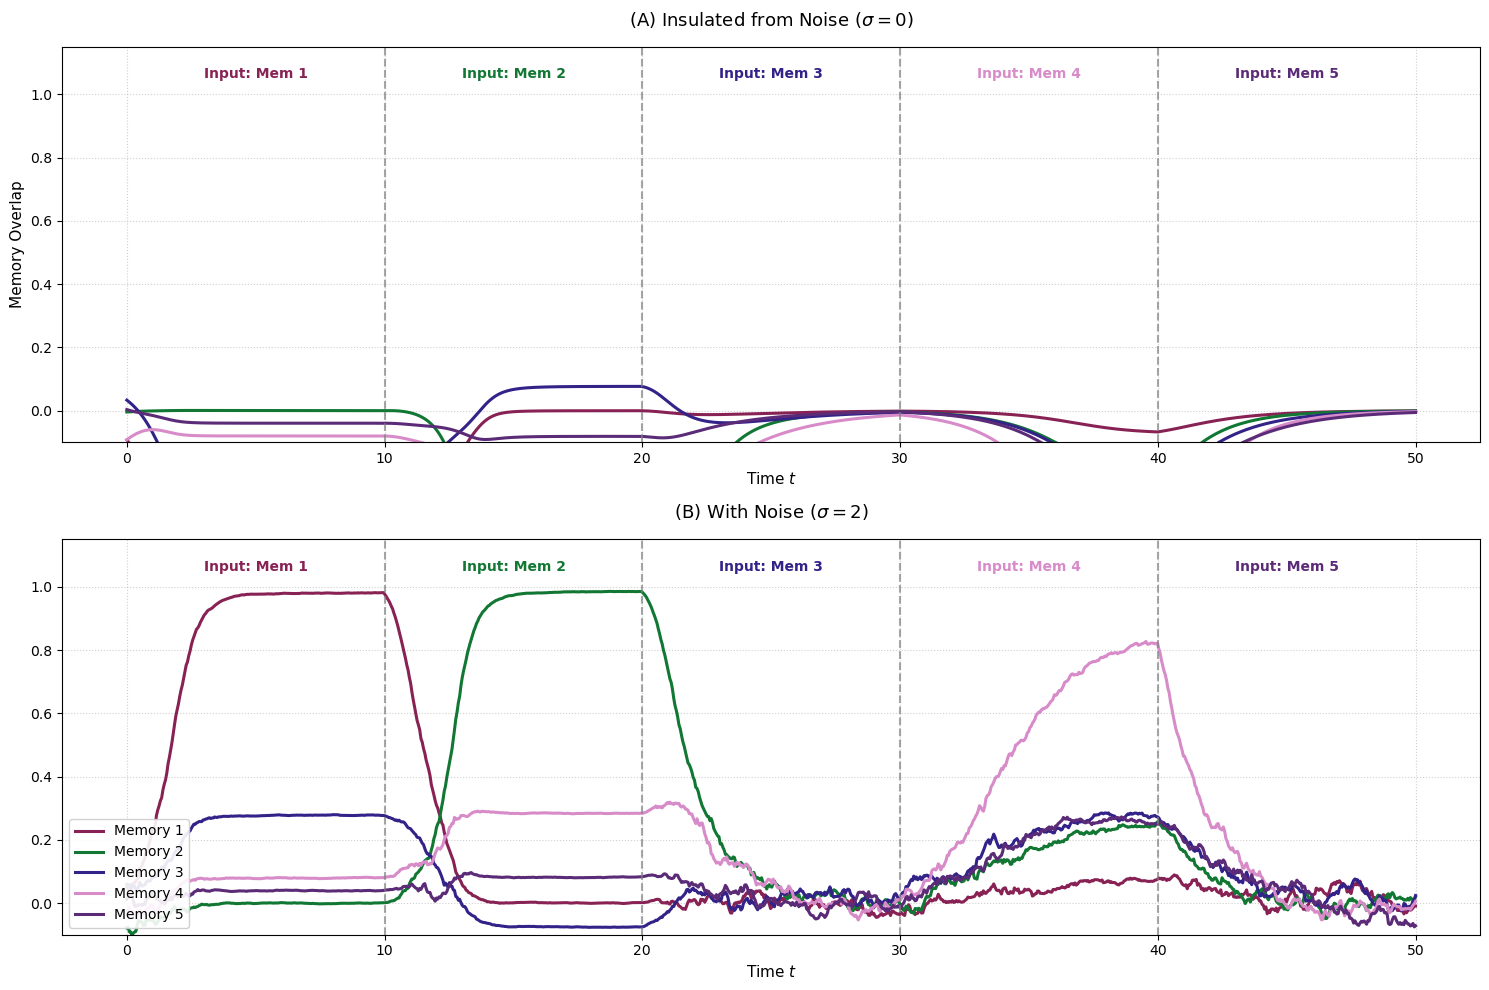

In [19]:
## Simulation of 5 Memories, still constant but more ambiguous

def run_simulation(xi, dt=0.05, T=50.0, sigma=0.3, N=1024, P=5):
    K = int(T / dt)
    time_points = np.linspace(0, T, K)
    
    # Initial state (random starting point)
    x = np.random.randn(N) * 0.1
    
    # Store history of overlaps: shape (K, P)
    overlap_history = np.zeros((K, P))
    
    for k in range(K):
        t = k * dt
        
        # 1. Define the input u(t) for current phase
        if t < 10.0:
            omega = np.array([3.0, 0.5, 0.4, 0.2, 0.1]) # Mem 1
        elif t < 20.0:
            omega = np.array([0.35, 3.0, 0.5, 0.6,0.9]) # Mem 2
        elif t < 30.0:
            omega = np.array([0.2, 0.1, 0.40, 1.4, 0.0]) # Mem 3
        elif t < 40.0:
            omega = np.array([0.2, 0.4, 0.00, 2.0, 1.2]) # Mem 4
        else:
            omega = np.array([0.2, 0.75, 0.90, 0.15, 1.25]) # Mem 5 (much smaller differences)
            
        u = xi @ omega /np.sqrt(N) # Mixture input
        
        # 2. Update synaptic matrix W(u)
        alpha = compute_saliency(xi, u)
        W = build_synaptic_matrix(xi, alpha, N)
        
        # 3. Step forward with SDE
        x = update_step(x, W, dt, sigma, N)
        
        # 4. Record the overlaps
        overlap_history[k, :] = compute_overlap(xi, x, N)
        
    return time_points, overlap_history
    

# 1. Generate patterns
np.random.seed(42)
N = 50
P = 5
xi = np.random.choice([-1.0, 1.0], size=(N, P))

# 2. Run both simulations
t_pts, hist_no_noise = run_simulation(xi, dt=0.05, T=50.0, sigma=0.0, N=N, P=P)
t_pts, hist_with_noise = run_simulation(xi, dt=0.05, T=50.0, sigma=0.05, N=N, P=P)

for t_idx in [0, 100, 200, 300, 400, 500]:
    t_val = t_pts[t_idx]
    print(f"t = {t_val:4.1f}s | Overlaps: {hist_with_noise[t_idx]}")


# 3. Plotting
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharey=True)
colors = ['#882255', '#117733', '#332288', '#d88bc9', '#5b2b77']  # Red, Green, Blue, Pink, Purple
labels = ['Memory 1', 'Memory 2', 'Memory 3', 'Memory 4', 'Memory 5']

for ax, hist, title in zip(axes, [hist_no_noise, hist_with_noise], 
                           ['(A) Insulated from Noise ($\sigma = 0$)', 
                            '(B) With Noise ($\sigma = 0.05$)']):
    for mu in range(P):
        ax.plot(t_pts, hist[:, mu], label=labels[mu], color=colors[mu], lw=2.2)
        
    # Vertical lines indicating input switches at t = 10 and t = 20
    ax.axvline(10, color='gray', linestyle='--', alpha=0.7)
    ax.axvline(20, color='gray', linestyle='--', alpha=0.7)
    ax.axvline(30, color='gray', linestyle='--', alpha=0.7)
    ax.axvline(40, color='gray', linestyle='--', alpha=0.7)
    
    # Visual cues for dominant input
    ax.text(5, 1.05, 'Input: Mem 1', ha='center', fontsize=10, weight='bold', color=colors[0])
    ax.text(15, 1.05, 'Input: Mem 2', ha='center', fontsize=10, weight='bold', color=colors[1])
    ax.text(25, 1.05, 'Input: Mem 3', ha='center', fontsize=10, weight='bold', color=colors[2])
    ax.text(35, 1.05, 'Input: Mem 4', ha='center', fontsize=10, weight='bold', color=colors[3])
    ax.text(45, 1.05, 'Input: Mem 5', ha='center', fontsize=10, weight='bold', color=colors[4])
    
    ax.set_title(title, fontsize=13, pad=15)
    ax.set_xlabel('Time $t$', fontsize=11)
    ax.set_ylim(-0.1, 1.15)
    ax.grid(True, linestyle=':', alpha=0.6)

axes[0].set_ylabel('Memory Overlap', fontsize=11)
axes[1].legend(loc='lower left', framealpha=0.9)

plt.tight_layout()
plt.show()


t =  0.0s | Overlaps: [ 0.09618059  0.01965803  0.02680094 -0.02003238  0.04289615]
t =  5.0s | Overlaps: [ 1.    0.    0.16  0.02 -0.02]
t = 10.0s | Overlaps: [ 9.99999448e-01 -9.13784034e-09  1.59999925e-01  2.00000284e-02
 -1.99999736e-02]
t = 15.0s | Overlaps: [ 0.    1.   -0.04  0.14 -0.1 ]
t = 20.0s | Overlaps: [ 0.    1.   -0.04  0.14 -0.1 ]
t = 25.0s | Overlaps: [-4.20280843e-11  9.99999998e-01 -3.99999999e-02  1.40000000e-01
 -9.99999998e-02]


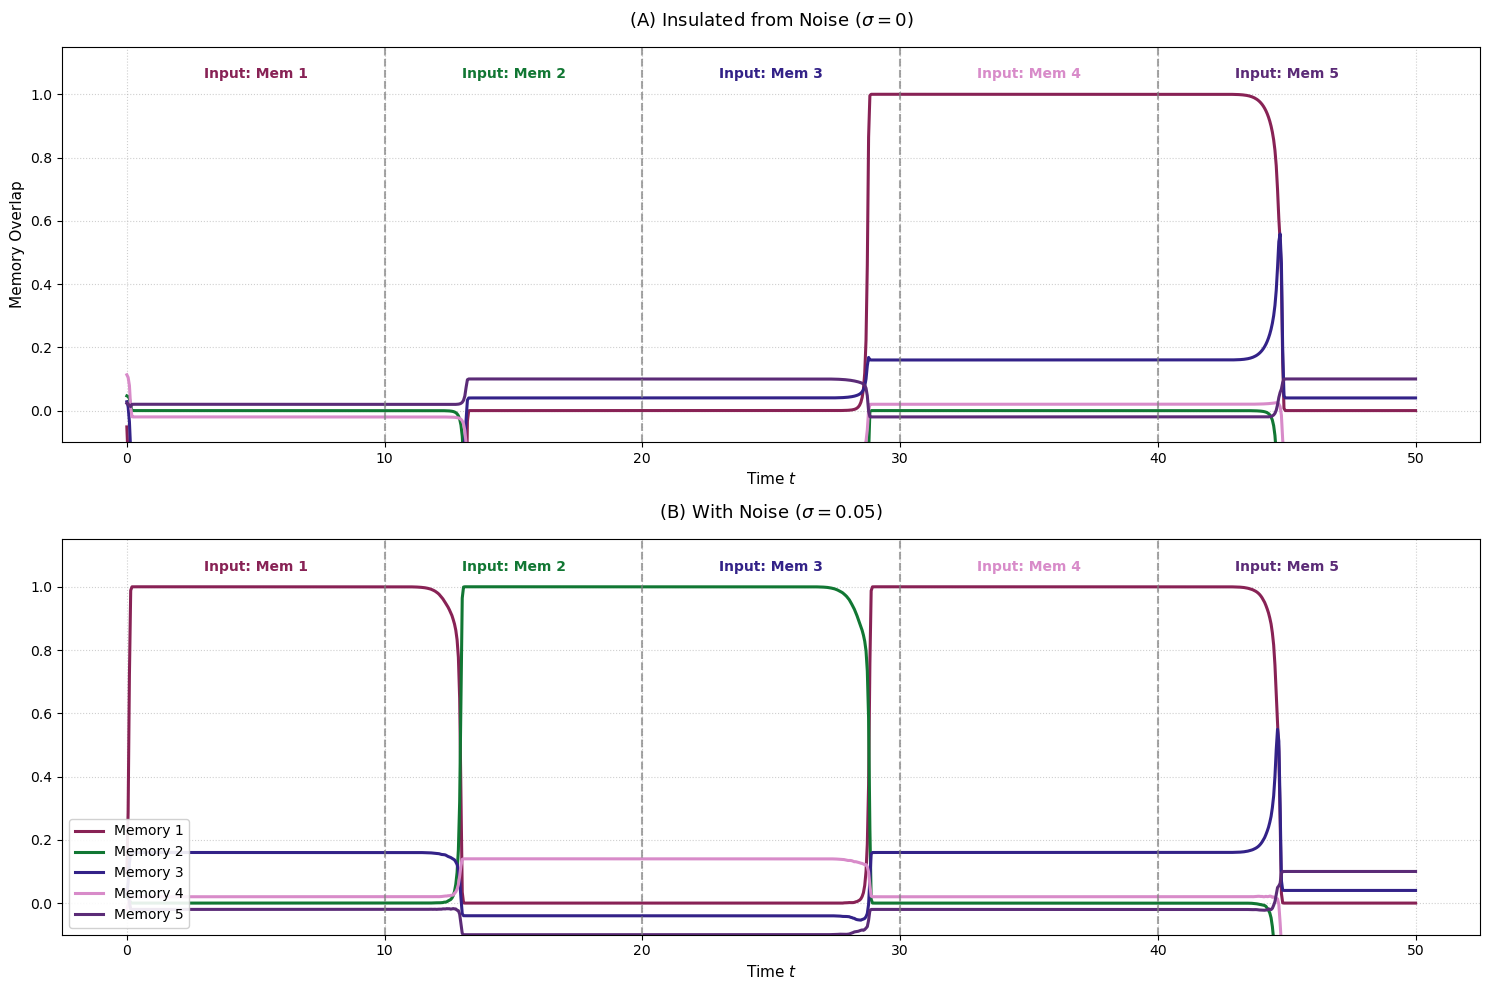

In [70]:
# 1. Generate patterns
np.random.seed(42)
N = 100
P = 5
xi = np.random.choice([-1.0, 1.0], size=(N, P))

# 2. Run both simulations
t_pts, hist_no_noise = run_simulation(xi, dt=0.05, T=50.0, sigma=0.0, N=N, P=P)
t_pts, hist_with_noise = run_simulation(xi, dt=0.05, T=50.0, sigma=0.05, N=N, P=P)

for t_idx in [0, 100, 200, 300, 400, 500]:
    t_val = t_pts[t_idx]
    print(f"t = {t_val:4.1f}s | Overlaps: {hist_with_noise[t_idx]}")


# 3. Plotting
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharey=True)
colors = ['#882255', '#117733', '#332288', '#d88bc9', '#5b2b77']  # Red, Green, Blue, Pink, Purple
labels = ['Memory 1', 'Memory 2', 'Memory 3', 'Memory 4', 'Memory 5']

for ax, hist, title in zip(axes, [hist_no_noise, hist_with_noise], 
                           ['(A) Insulated from Noise ($\sigma = 0$)', 
                            '(B) With Noise ($\sigma = 0.05$)']):
    for mu in range(P):
        ax.plot(t_pts, hist[:, mu], label=labels[mu], color=colors[mu], lw=2.2)
        
    # Vertical lines indicating input switches at t = 10 and t = 20
    ax.axvline(10, color='gray', linestyle='--', alpha=0.7)
    ax.axvline(20, color='gray', linestyle='--', alpha=0.7)
    ax.axvline(30, color='gray', linestyle='--', alpha=0.7)
    ax.axvline(40, color='gray', linestyle='--', alpha=0.7)
    
    # Visual cues for dominant input
    ax.text(5, 1.05, 'Input: Mem 1', ha='center', fontsize=10, weight='bold', color=colors[0])
    ax.text(15, 1.05, 'Input: Mem 2', ha='center', fontsize=10, weight='bold', color=colors[1])
    ax.text(25, 1.05, 'Input: Mem 3', ha='center', fontsize=10, weight='bold', color=colors[2])
    ax.text(35, 1.05, 'Input: Mem 4', ha='center', fontsize=10, weight='bold', color=colors[3])
    ax.text(45, 1.05, 'Input: Mem 5', ha='center', fontsize=10, weight='bold', color=colors[4])
    
    ax.set_title(title, fontsize=13, pad=15)
    ax.set_xlabel('Time $t$', fontsize=11)
    ax.set_ylim(-0.1, 1.15)
    ax.grid(True, linestyle=':', alpha=0.6)

axes[0].set_ylabel('Memory Overlap', fontsize=11)
axes[1].legend(loc='lower left', framealpha=0.9)

plt.tight_layout()
plt.show()

This 5-memory example is much less clean than the original test, with smaller differences in saliency than the original. We found that for this much more ambiguous dataset, noise had to be very small before the saliency metric fell apart, and that it did preserve some behavior (Memory 1, 2, and 4 as most salient) than without the noise present. However, we were working with a very small N (N = 50) in previous trials; when even just doubling the neurons, it's able to tell between the more ambiguous inputs.

In [52]:
# Simulation of 3 constantly changing memories & correlations

def omega_fn(t):
    return np.array([
        np.sin(t),
        np.maximum(0, t/50), # relu
        np.sqrt(t),
    ])

def run_simulation(xi, dt=0.05, T=50.0, sigma=0.3, N=3000, P=5):
    K = int(T / dt)
    time_points = np.linspace(0, T, K)

    # Initial state (random starting point)
    x = np.random.randn(N) * 0.1
    
    # Store history of overlaps: shape (K, P)
    overlap_history = np.zeros((K, P))
    
    for k in range(K):
        t = k * dt
        omega = omega_fn(xi,t)
        u = xi @ omega /np.sqrt(N) # Mixture input
        
        # 2. Update synaptic matrix W(u)
        alpha = compute_saliency(xi, u)
        W = build_synaptic_matrix(xi, alpha, N)
        
        # 3. Step forward with SDE
        x = update_step(x, W, dt, sigma, N)
        
        # 4. Record the overlaps
        overlap_history[k, :] = compute_overlap(xi, x, N)
    
    return time_points, overlap_history

t =  0.0s | Overlaps: [0.01686285 0.10735123 0.03567844]
t =  5.0s | Overlaps: [0.01704398 0.01093279 0.09022445]
t = 10.0s | Overlaps: [0.13998367 0.05999209 0.99971955]
t = 15.0s | Overlaps: [0.14000011 0.06       0.99999908]
t = 20.0s | Overlaps: [0.14       0.06       0.99999999]
t = 25.0s | Overlaps: [0.14 0.06 1.  ]


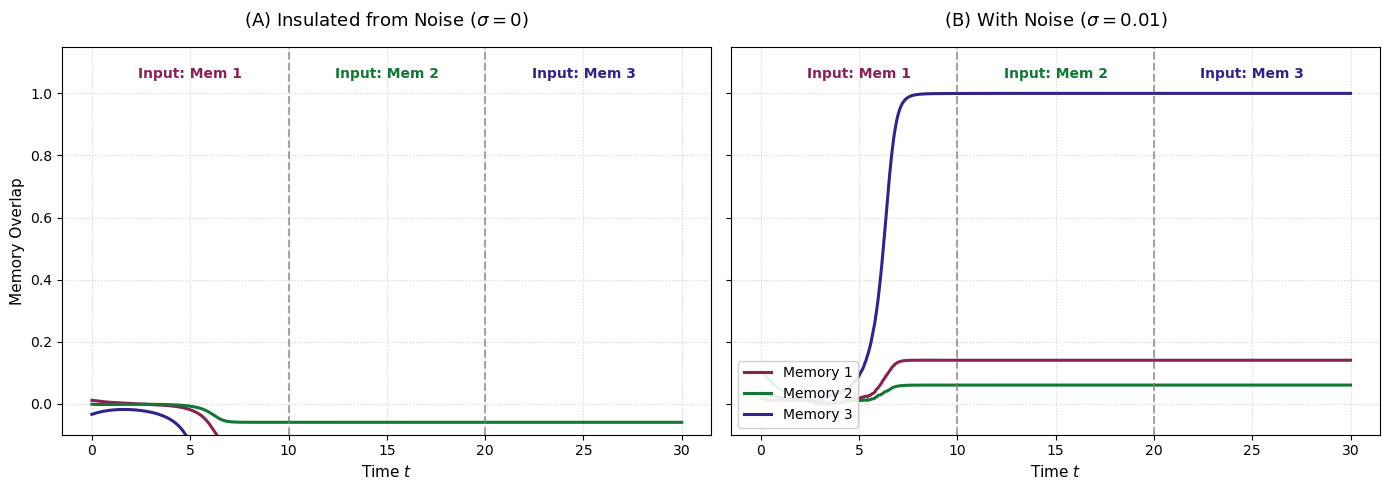

In [53]:
## Test w/ random pattern
np.random.seed(42)
N = 100
P = 3
xi = np.random.choice([-1.0, 1.0], size=(N, P))

# Run both simulations
t_pts, hist_no_noise = run_simulation(xi, dt=0.05, T=30.0, sigma=0.0, N=N, P=P)
t_pts, hist_with_noise = run_simulation(xi, dt=0.05, T=30.0, sigma=0.01, N=N, P=P)

for t_idx in [0, 100, 200, 300, 400, 500]:
    t_val = t_pts[t_idx]
    print(f"t = {t_val:4.1f}s | Overlaps: {hist_with_noise[t_idx]}")


# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors = ['#882255', '#117733', '#332288']  # Red, Green, Blue
labels = ['Memory 1', 'Memory 2', 'Memory 3']


for ax, hist, title in zip(axes, [hist_no_noise, hist_with_noise], 
                           ['(A) Insulated from Noise ($\sigma = 0$)', 
                            '(B) With Noise ($\sigma = 0.01$)']):
    for mu in range(P):
        ax.plot(t_pts, hist[:, mu], label=labels[mu], color=colors[mu], lw=2.2)
        
    # Vertical lines indicating input switches at t = 10 and t = 20
    ax.axvline(10, color='gray', linestyle='--', alpha=0.7)
    ax.axvline(20, color='gray', linestyle='--', alpha=0.7)
    
    # Visual cues for dominant input
    ax.text(5, 1.05, 'Input: Mem 1', ha='center', fontsize=10, weight='bold', color=colors[0])
    ax.text(15, 1.05, 'Input: Mem 2', ha='center', fontsize=10, weight='bold', color=colors[1])
    ax.text(25, 1.05, 'Input: Mem 3', ha='center', fontsize=10, weight='bold', color=colors[2])
    
    ax.set_title(title, fontsize=13, pad=15)
    ax.set_xlabel('Time $t$', fontsize=11)
    ax.set_ylim(-0.1, 1.15)
    ax.grid(True, linestyle=':', alpha=0.6)

axes[0].set_ylabel('Memory Overlap', fontsize=11)
axes[1].legend(loc='lower left', framealpha=0.9)

plt.tight_layout()
plt.show()

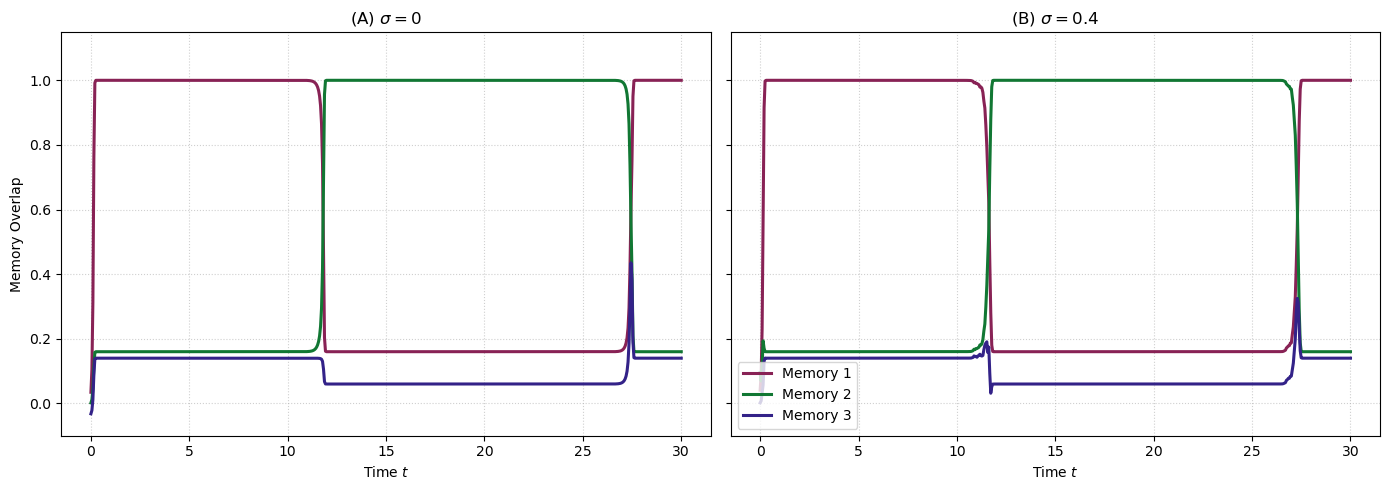

In [71]:
# Repeat w/ a more coherent xi 
P = 3

def run_simulation(xi, dt=0.05, T=30.0, sigma=0.3, N=50, P=5):
    K = int(T / dt)
    time_points = np.linspace(0, T, K)

    x = np.random.randn(N) * 0.1
    overlap_history = np.zeros((K, P))

    for k in range(K):
        t = k * dt

        # input with spatial structure: slowly goes from memory 1 -> 2 -> 3
        u = (np.cos(0.1 * t) ** 2) * xi[:, 0] \
          + (np.sin(0.1 * t) ** 2) * xi[:, 1] \
          + np.maximum(0, t / T - 0.5) * xi[:, 2]

        alpha = compute_saliency(xi, u)
        W = build_synaptic_matrix(xi, alpha, N)
        x = update_step(x, W, dt, sigma, N)
        overlap_history[k, :] = compute_overlap(xi, x, N)

    return time_points, overlap_history

np.random.seed(42)
N, P = 100, 3
xi = np.random.choice([-1.0, 1.0], size=(N, P))

t_pts, hist_no_noise   = run_simulation(xi, T=30.0, sigma=0.0,  N=N, P=P)
t_pts, hist_with_noise = run_simulation(xi, T=30.0, sigma=0.4, N=N, P=P)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors = ['#882255', '#117733', '#332288']  # Red, Green, Blue
labels = ['Memory 1', 'Memory 2', 'Memory 3']

for ax, hist, title in zip(axes, [hist_no_noise, hist_with_noise],
                           [r'(A) $\sigma = 0$', r'(B) $\sigma = 0.4$']):
    for mu in range(P):
        ax.plot(t_pts, hist[:, mu], color=colors[mu], lw=2.2, label=f'Memory {mu+1}')
    ax.set_title(title)
    ax.set_xlabel('Time $t$')
    ax.set_ylim(-0.1, 1.15)
    ax.grid(True, linestyle=':', alpha=0.6)
    
axes[0].set_ylabel('Memory Overlap')
axes[1].legend(loc='lower left')
plt.tight_layout()
plt.show()

Works! Even though we implement the third function, the mixed input is always periodic, which will match closer to memory 1 and 2 always.